In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
import pandas as pd

from cnn_surgery.lenses.regressor_lens import get_regressor_lens, mse_mae
from cnn_surgery.utils.evaluate_per_class_accuracy import evaluate_classifier, load_testset_data
from cnn_surgery.utils.load_dataset import load_dataset, load_multi_stage_dataset, find_best_model_index
from cnn_surgery.utils.reconstruct_network import reconstruct_network

DATASET = "mnist"

In [2]:
def test_network_accuracy(weights: np.ndarray | torch.Tensor, activation_fn):
    """
    Reconstructs a network from weights and activation function, evaluates it on the test set
    BEWARE: when using it in unlearning, the input could be a tensor, so be sure to convert it to numpy array first:
        weights = weights.detach().numpy()

    Returns:
        mean accuracy: float
        per class accuracies: list of floats
    """

    if isinstance(weights, torch.Tensor):
        weights = weights.detach().numpy()

    CNNModel = reconstruct_network(weights, activation_fn)
    # this returns a Keras model (Unterthiner code), we have to compile it first
    CNNModel.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    x_test, y_test = load_testset_data(DATASET)
    overall_acc, class_accs = evaluate_classifier(CNNModel, x_test, y_test)
    return overall_acc, class_accs

Visualize data samples from the dataset.

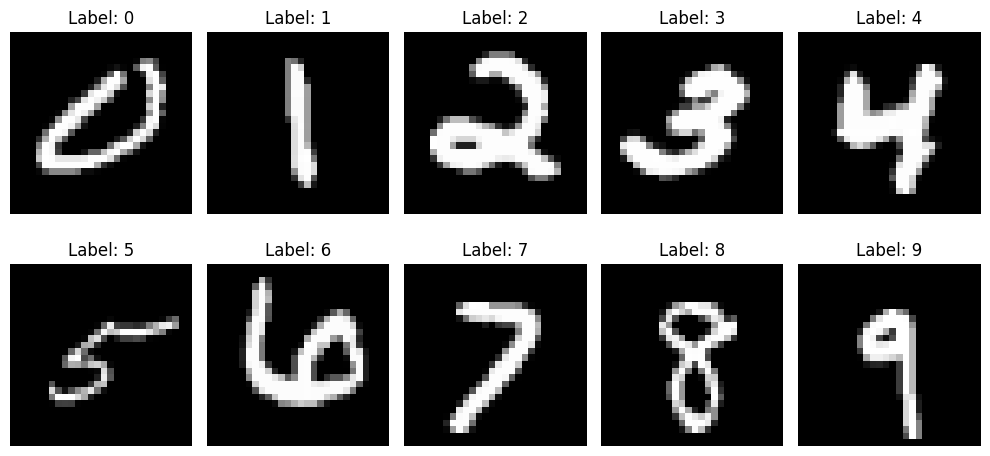

In [3]:
x_test, y_test = load_testset_data(DATASET)

figure, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    label = i
    mask = y_test == label
    samples = x_test[np.argwhere(mask)]
    sample = samples[np.random.randint(len(samples))][0] # starts with a nonce dimension for some reason
    ax = axes[i // 5, i % 5]
    ax.imshow(sample, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

Load dataset and train model

In [5]:
train, val, test = load_multi_stage_dataset(include_test=True, dataset=DATASET).values()

weights_train = train[0]
weights_val = val[0]
weights_test = test[0]

accuracies_train = train[1]
accuracies_val = val[1]
accuracies_test = test[1]

configs_train = train[2]
configs_val = val[2]
configs_test = test[2]

RegressorLens = get_regressor_lens(weights_train, accuracies_train, weights_val, accuracies_val, device='cpu')

dirname:  /Users/moos/Desktop/snijzaal/WeightSpaceClassifier/model_zoo/mnist


dirname:  /Users/moos/Desktop/snijzaal/WeightSpaceClassifier/model_zoo/mnist


dirname:  /Users/moos/Desktop/snijzaal/WeightSpaceClassifier/model_zoo/mnist



Starting training of RegressorLens:
Epoch   1 ─ val loss 0.026916 | val MAE 0.096573 | duration 1.4s
Epoch   2 ─ val loss 0.022613 | val MAE 0.082822 | duration 1.1s
Epoch   3 ─ val loss 0.020624 | val MAE 0.078457 | duration 1.1s
Epoch   4 ─ val loss 0.019318 | val MAE 0.072367 | duration 1.1s
Epoch   5 ─ val loss 0.017296 | val MAE 0.069701 | duration 1.2s
Epoch   6 ─ val loss 0.017253 | val MAE 0.070144 | duration 1.1s
Epoch   7 ─ val loss 0.015711 | val MAE 0.063612 | duration 1.1s
Epoch   8 ─ val loss 0.016116 | val MAE 0.064099 | duration 1.1s
Epoch   9 ─ val loss 0.016262 | val MAE 0.062159 | duration 1.1s
Epoch  10 ─ val loss 0.015211 | val MAE 0.062395 | duration 1.1s
Epoch  11 ─ val loss 0.015404 | val MAE 0.060919 | duration 1.2s
Epoch  12 ─ val loss 0.014876 | val MAE 0.060076 | duration 1.1s
Epoch  13 ─ val loss 0.015140 | val MAE 0.059992 | duration 1.1s
Epoch  14 ─ val loss 0.015978 | val MAE 0.061556 | duration 1.1s
Epoch  15 ─ val loss 0.014726 | val MAE 0.059759 | du

In [7]:
# # find the index of the best-performing model in the test set
# def find_best_model_index():
#     _, _, val_early = load_dataset(DATASET, metrics_file='metrics_merged_early.csv', load_class_acc=True, stage='early')
#     _, _, val_middle = load_dataset(DATASET, metrics_file='metrics_merged_middle.csv', load_class_acc=True, stage='middle')
#     _, _, val_final = load_dataset(DATASET, metrics_file='metrics_merged_final.csv', load_class_acc=True, stage='final')

#     overall_accuracies_val = np.concatenate([val_early[1][:, 0], val_middle[1][:, 0], val_final[1][:, 0]])

#     best_model_idx = np.argmax(overall_accuracies_val)
#     print(f"Best model index in validation set: {best_model_idx}, mean accuracy: {overall_accuracies_val[best_model_idx]}")
#     return best_model_idx

MODEL_IDX = find_best_model_index(DATASET, partition="test")

dirname:  /Users/moos/Desktop/snijzaal/WeightSpaceClassifier/model_zoo/mnist


dirname:  /Users/moos/Desktop/snijzaal/WeightSpaceClassifier/model_zoo/mnist


dirname:  /Users/moos/Desktop/snijzaal/WeightSpaceClassifier/model_zoo/mnist


Best model index in test set: 16384, accuracy: 0.9857000112533569


Loss functions

In [8]:
from jaxtyping import Float, Array

# ----- loss functions -----
simple_loss = lambda pred, target_idx: pred[target_idx]  # minimize the accuracy of the target class

def simple_loss(pred, target_idx):
    return pred[target_idx]  # minimize the accuracy of the target class

def unlearning_and_faithfulness_loss(pred, true, target_idx, beta=1.0):  # needs a better name
    target_term = pred[target_idx]  # we want to minimize this

    # mse = ((true - pred) ** 2).mean()  # we want the regressorlens to remain faithful to the actual performance
    mae = (true - pred).abs().mean()

    # return target_term + mse
    return target_term + beta * mae  # minimize predicted target performance

def boost_loss(pred, target_idx, beta=1.0):
    target_term = pred[target_idx]  # we want to minimize this

    # set target index zero for this term by multiplying with a mask
    mask = torch.ones_like(pred, requires_grad=False)
    mask[target_idx] = 0
    maintain_rest_term = (pred * mask).sum()  # we want to increase or at least maintain the accuracy of the other classes

    return target_term - beta * maintain_rest_term

def unlearning_metric(before_accs, after_accs, target_idx: int):

    target_term: float = -1 * min((after_accs[target_idx] - before_accs[target_idx]), 0)
    
    rest_before_accs = np.delete(before_accs, target_idx)
    rest_after_accs = np.delete(after_accs, target_idx)
    x = np.clip(rest_after_accs - rest_before_accs, a_min=None, a_max=0)
    maintain_rest_term = -1 * np.mean(x)
    return target_term - maintain_rest_term

unlearning

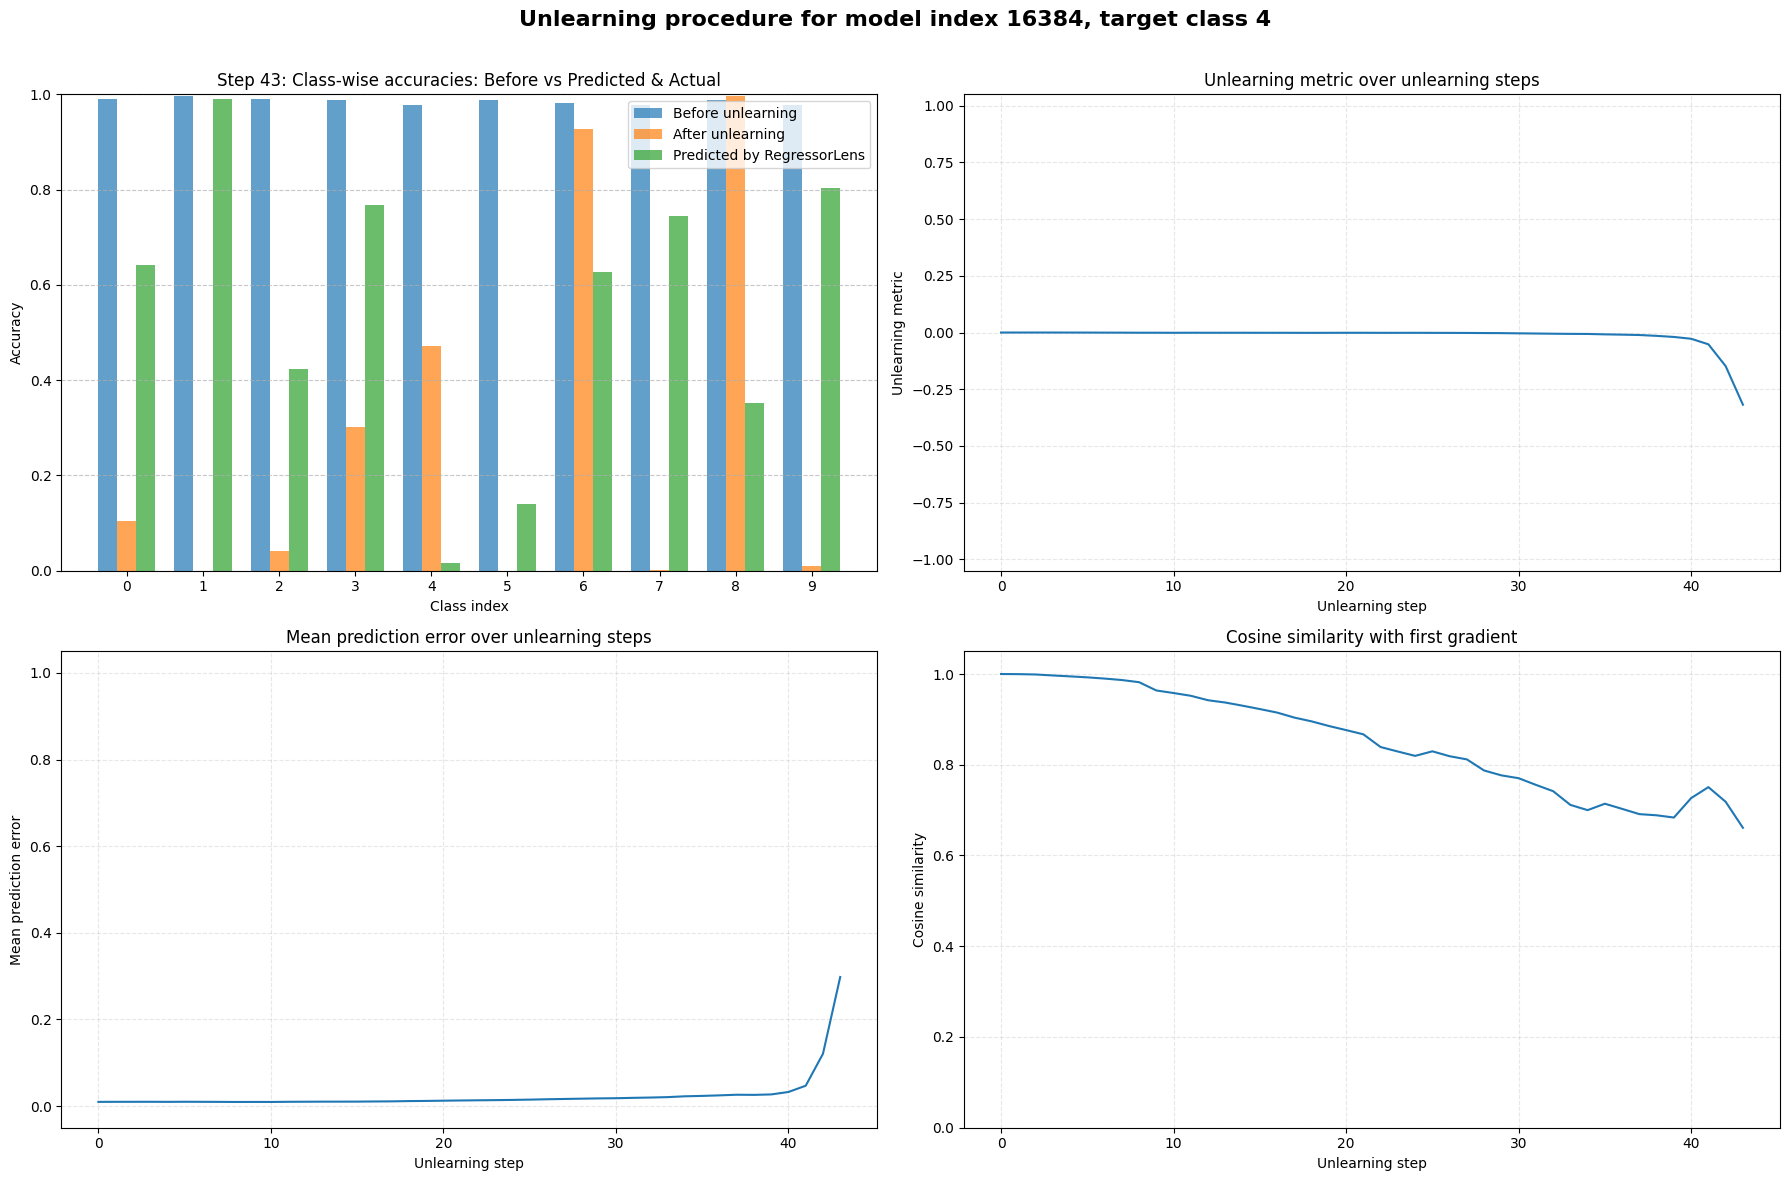

Stopping early at step 44 due cosine similarity below threshold (-0.0310 < 0.6)


In [10]:
from IPython.display import clear_output, display
from matplotlib.pyplot import axes

assert isinstance(RegressorLens, nn.Module), f"RegressorLens is not an instance of torch.nn.Module but {type(RegressorLens)}"
input_weights: np.ndarray = weights_test[MODEL_IDX]
# inputs_weights: np.ndarray = weights_val[MODEL_IDX]
steps: int = 100
step_size: float = 10
target_class: int = 4
og_config: pd.Series = configs_test.iloc[MODEL_IDX]
# og_config: pd.Series = configs_val.iloc[MODEL_IDX]
beta = 0.1
stop_threshold = 0.6
animate = True

"""
    input_weights: np.ndarray, weights of the model to be unlearned
    steps: int - number of optimization steps
    lens: torch.nn.Module - pretrained regressor lens model
    step_size: float - step size for the optimization
    target_class: int - class index to be unlearned
    og_config - original configuration of the model to be unlearned (for reconstructing the model)
"""

print("Starting unlearning procedure")
diffs_list = []
loss_list = []
target_term_list = []
# mse_term_list = []
mae_term_list = []
cosine_sim_list = []
metric_list = []
maintain_rest_list = []

before_accs = test_network_accuracy(input_weights, og_config["config.activation"])[1]

# convert input weights to tensor for optimization
doctored_input_weights = torch.tensor(input_weights, requires_grad=True, dtype=torch.float32)
RegressorLens.eval()

# optimize only the INPUT weights
for param in RegressorLens.parameters():
    param.requires_grad = False

# for i in tqdm(range(steps), desc="Unlearning in progress"):
for i in range(steps): 

    # this is expensive: a new model needs to be reconstructed and evaluated at every step
    true = torch.tensor(
        test_network_accuracy(doctored_input_weights.detach().numpy(), og_config["config.activation"])[1],
        dtype=torch.float32,
    )

    pred: torch.Tensor = RegressorLens(doctored_input_weights.unsqueeze(0)).squeeze(0)  # forward pass
    loss = boost_loss(pred, target_class, beta=beta)
    loss.backward()  # compute gradients

    gradient = doctored_input_weights.grad.clone() # type: ignore
    if i == 0:
        first_gradient = gradient

    ### ACTUAL OPTIMIZATION STEP ###
    with torch.no_grad():
        doctored_input_weights -= step_size * gradient  # gradient step # type: ignore
        doctored_input_weights.grad.zero_()  # zero gradients # type:  ignore

    # stopping criterion: cosine_similarity between gradient and first gradient should stay below a threshold
    cos_sim = np.dot(gradient, first_gradient) / (np.linalg.norm(gradient) * np.linalg.norm(first_gradient))
    if cos_sim < stop_threshold:
        print(f"Stopping early at step {i} due cosine similarity below threshold ({cos_sim:.4f} < {stop_threshold})")
        break

    # -------- for analysis --------
    target_term: float = pred[target_class].item()
    # mse_term: float = ((true - pred) ** 2).mean().item()
    mae_term: float = (true - pred).abs().mean().item()
    mean_diff = abs((pred.detach().numpy() - np.array(true.detach().numpy()))).mean()
    metric = unlearning_metric(np.array(before_accs), true.detach().numpy(), target_class)
    mask = torch.ones_like(pred, requires_grad=False)
    mask[target_class] = 0
    maintain_rest_term = beta * -1 * (pred * mask).sum().item()

    loss_list.append(loss.item())
    target_term_list.append(target_term)
    # mse_term_list.append(mse_term)
    mae_term_list.append(mae_term)
    diffs_list.append(mean_diff)
    cosine_sim_list.append(cos_sim)
    metric_list.append(metric)
    maintain_rest_list.append(maintain_rest_term)

    if animate:
        # ------- plot -------
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))

        before_accs = accuracies_test[MODEL_IDX]
        # before_accs = accuracies_val[MODEL_IDX]
        assert isinstance(RegressorLens, nn.Module), f"RegressorLens is not an instance of torch.nn.Module but {type(RegressorLens)}"
        preds = RegressorLens(doctored_input_weights.unsqueeze(0)).squeeze().detach().numpy()
        actual_accs = test_network_accuracy(doctored_input_weights.detach().numpy(), og_config["config.activation"])[1]

        classes = np.arange(len(preds))
        bar_width = 0.25
        ax = axes[0, 0]
        ax.bar(classes - bar_width, before_accs, width=bar_width, label="Before unlearning", alpha=0.7)
        ax.bar(classes,              actual_accs, width=bar_width, label="After unlearning", alpha=0.7)
        ax.bar(classes + bar_width,  preds,       width=bar_width, label="Predicted by RegressorLens", alpha=0.7)
        ax.set_xlabel("Class index")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"Step {i}: Class-wise accuracies: Before vs Predicted & Actual")
        ax.set_xticks(classes)
        ax.set_ylim(0, 1)
        ax.grid(axis="y", linestyle="--", alpha=0.7)
        ax.legend()

        # ------- (2,0) unlearning metric -------
        ax = axes[0, 1]
        ax.plot(metric_list)
        ax.set_xlabel("Unlearning step")
        ax.set_ylabel("Unlearning metric")
        ax.set_title("Unlearning metric over unlearning steps")
        ax.set_ylim(-1.05, 1.05)
        ax.grid(linestyle="--", alpha=0.3)

        ax = axes[1, 0]
        ax.plot(diffs_list)
        ax.set_xlabel("Unlearning step")
        ax.set_ylabel("Mean prediction error")
        ax.set_title("Mean prediction error over unlearning steps")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(linestyle="--", alpha=0.3)

        ax = axes[1, 1]
        ax.plot(cosine_sim_list)
        ax.set_xlabel("Unlearning step")
        ax.set_ylabel("Cosine similarity")
        ax.set_title("Cosine similarity with first gradient")
        ax.set_ylim(0, 1.05)
        ax.grid(linestyle="--", alpha=0.3)

        fig.suptitle(f"Unlearning procedure for model index {MODEL_IDX}, target class {target_class}", fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.97]) # type: ignore

        display(fig)

        # input("Press Enter to continue to the next step...")

        plt.close(fig)

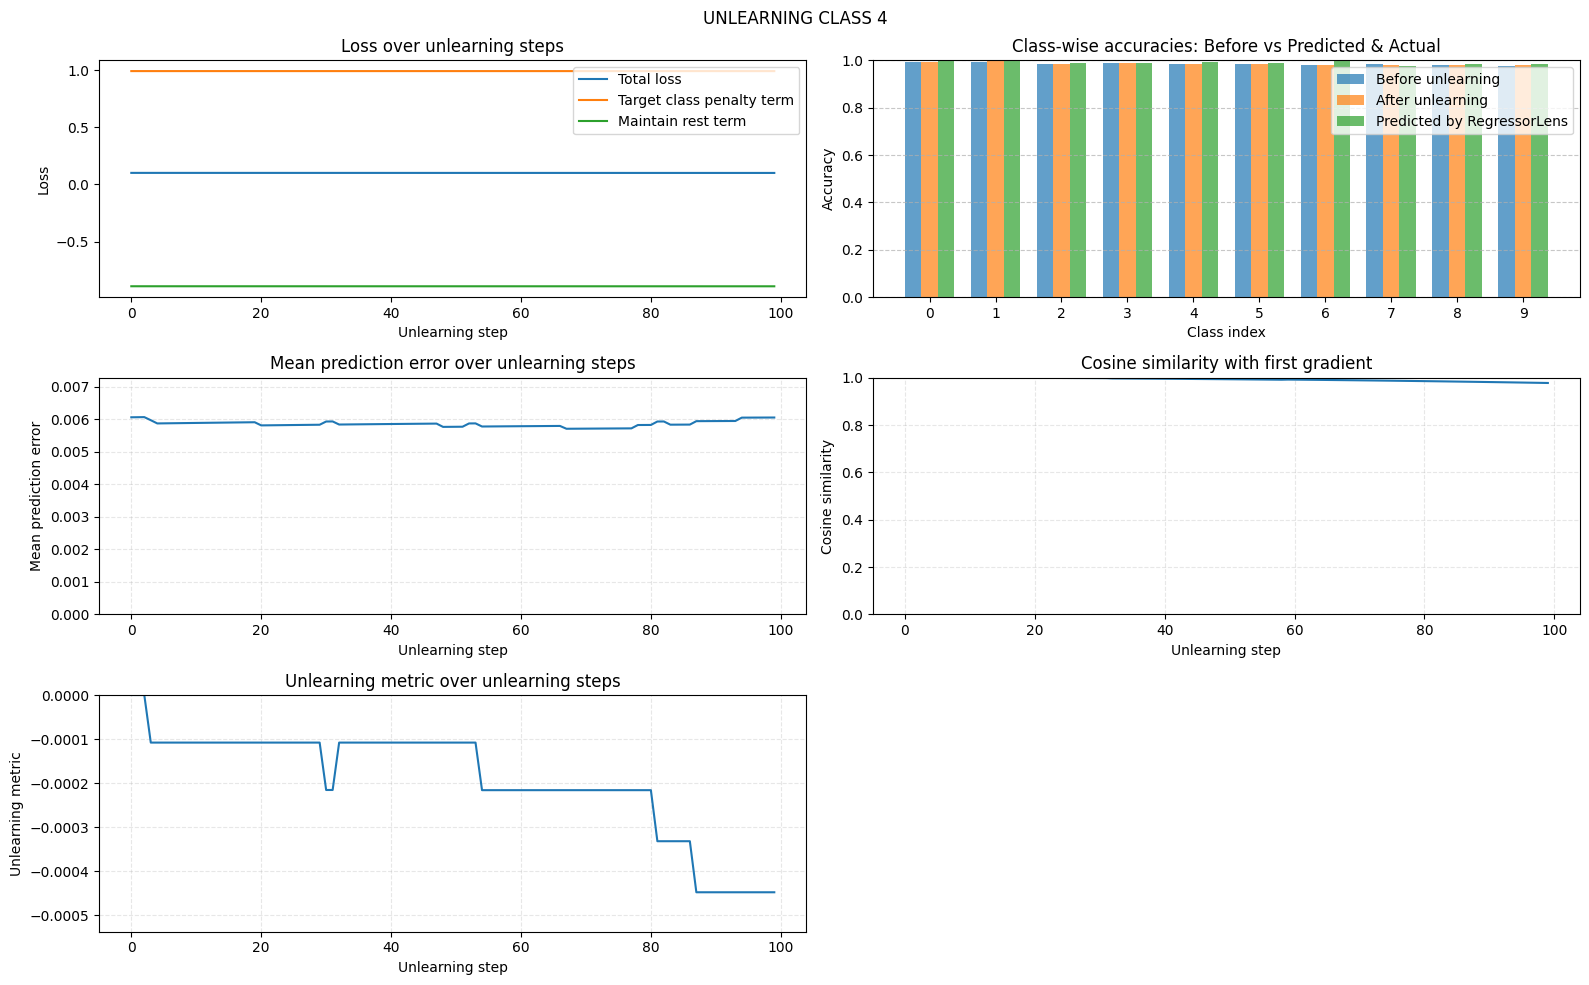

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle(F"UNLEARNING CLASS {target_class}")

# ------- (0,0) loss plotting -------
ax = axes[0, 0]
ax.plot(loss_list, label="Total loss")
ax.plot(target_term_list, label="Target class penalty term")
ax.plot(maintain_rest_list, label="Maintain rest term")
# ax.plot(mse_term_list, label="MSE (RegressorLens faithfulness) term")
# ax.plot(mae_term_list, label="MAE (RegressorLens faithfulness) term")
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Loss")
ax.set_title("Loss over unlearning steps")
# ax.set_ylim(min(loss_list) * 1.2, max(loss_list) * 1.2)
ax.legend()

# ------- (0,1) accuracy -------
before_accs = accuracies_val[MODEL_IDX]
assert isinstance(RegressorLens, nn.Module), f"RegressorLens is not an instance of torch.nn.Module but {type(RegressorLens)}"
preds = RegressorLens(doctored_input_weights.unsqueeze(0)).squeeze().detach().numpy()
actual_accs = test_network_accuracy(doctored_input_weights.detach().numpy(), configs_val.iloc[MODEL_IDX]["config.activation"])[1]

ax = axes[0, 1]
classes = np.arange(len(preds))
bar_width = 0.25
ax.bar(classes - bar_width, before_accs, width=bar_width, label="Before unlearning", alpha=0.7)
ax.bar(classes,              actual_accs, width=bar_width, label="After unlearning", alpha=0.7)
ax.bar(classes + bar_width,  preds,       width=bar_width, label="Predicted by RegressorLens", alpha=0.7)
ax.set_xlabel("Class index")
ax.set_ylabel("Accuracy")
ax.set_title("Class-wise accuracies: Before vs Predicted & Actual")
ax.set_xticks(classes)
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()

# ------- (1,0) mean prediction error -------
ax = axes[1, 0]
ax.plot(diffs_list)
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Mean prediction error")
ax.set_title("Mean prediction error over unlearning steps")
ax.set_ylim(0, max(diffs_list) * 1.2 if len(diffs_list) else 1)
ax.grid(linestyle="--", alpha=0.3)

# ------- (1,1) gradient cosine similarity -------
ax = axes[1, 1]
ax.plot(cosine_sim_list)
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity with first gradient")
ax.set_ylim(0, 1)
ax.grid(linestyle="--", alpha=0.3)

# ------- (2,0) unlearning metric -------
ax = axes[2, 0]
ax.plot(metric_list)
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Unlearning metric")
ax.set_title("Unlearning metric over unlearning steps")
ax.set_ylim(min(metric_list) * 1.2, max(metric_list) * 1.2)
ax.grid(linestyle="--", alpha=0.3)

# hide the (2,1) subplot (bottom right)
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()


## testing more models

In [11]:
assert isinstance(RegressorLens, nn.Module), f"RegressorLens is not an instance of torch.nn.Module but {type(RegressorLens)}"
good_models_start_idx = round(len(weights_val) * (2/3))
n_models_to_test = 10
model_idxs = np.random.randint(good_models_start_idx, len(weights_val), size=n_models_to_test)
steps: int = 100
step_size: float = 1
target_class: int = 4
beta = 0.1
stop_threshold = 0.6

diffs_all = []
loss_all = []
target_term_all = []
mae_term_all = []
cosine_sim_all = []
metric_all = []
maintain_rest_all = []
before_accs_all = []
actual_accs_all = []

# for MODEL_IDX in model_idxs:
MODEL_IDX = 16385
for i in tqdm(range(n_models_to_test)):

    input_weights: np.ndarray = weights_val[MODEL_IDX]
    og_config: pd.Series = configs_val.iloc[MODEL_IDX]

    print("Starting unlearning procedure")
    diffs_list = []
    loss_list = []
    target_term_list = []
    # mse_term_list = []
    mae_term_list = []
    cosine_sim_list = []
    metric_list = []
    maintain_rest_list = []

    before_accs = test_network_accuracy(input_weights, og_config["config.activation"])[1]

    # convert input weights to tensor for optimization
    doctored_input_weights = torch.tensor(input_weights, requires_grad=True, dtype=torch.float32)
    RegressorLens.eval()

    # optimize only the INPUT weights
    for param in RegressorLens.parameters():
        param.requires_grad = False

    for i in tqdm(range(steps), desc="Unlearning in progress"):
        
        # this is expensive: a new model needs to be reconstructed and evaluated at every step
        true = torch.tensor(
            test_network_accuracy(doctored_input_weights.detach().numpy(), og_config["config.activation"])[1],
            dtype=torch.float32,
        )

        pred: torch.Tensor = RegressorLens(doctored_input_weights.unsqueeze(0)).squeeze(0)  # forward pass
        loss = boost_loss(pred, target_class, beta=beta)
        loss.backward()  # compute gradients

        gradient = doctored_input_weights.grad.clone()
        if i == 0:
            first_gradient = gradient

        ### ACTUAL OPTIMIZATION STEP ###
        with torch.no_grad():
            doctored_input_weights -= step_size * gradient  # gradient step # type: ignore
            doctored_input_weights.grad.zero_()  # zero gradients # type:  ignore

            # stopping criterion: cosine_similarity between gradient and first gradient should stay below a threshold
        cos_sim = np.dot(gradient, first_gradient) / (np.linalg.norm(gradient) * np.linalg.norm(first_gradient))
        if cos_sim < stop_threshold:
            print(f"Stopping early at step {i} due cosine similarity below threshold ({cos_sim:.4f} < {stop_threshold})")
            break

        # -------- for analysis --------
        target_term: float = pred[target_class].item()
        # mse_term: float = ((true - pred) ** 2).mean().item()
        mae_term: float = (true - pred).abs().mean().item()
        mean_diff = abs((pred.detach().numpy() - np.array(true.detach().numpy()))).mean()
        metric = unlearning_metric(np.array(before_accs), true.detach().numpy(), target_class)
        mask = torch.ones_like(pred, requires_grad=False)
        mask[target_class] = 0
        maintain_rest_term = beta * -1 * (pred * mask).sum().item()

        loss_list.append(loss.item())
        target_term_list.append(target_term)
        # mse_term_list.append(mse_term)
        mae_term_list.append(mae_term)
        diffs_list.append(mean_diff)
        cosine_sim_list.append(cos_sim)
        metric_list.append(metric)
        maintain_rest_list.append(maintain_rest_term)

    diffs_all.append(diffs_list)
    loss_all.append(loss_list)
    target_term_all.append(target_term_list)
    mae_term_all.append(mae_term_list)
    cosine_sim_all.append(cosine_sim_list)
    metric_all.append(metric_list)
    maintain_rest_all.append(maintain_rest_list)



  0%|          | 0/10 [00:00<?, ?it/s]

Starting unlearning procedure


 10%|█         | 1/10 [00:03<00:30,  3.37s/it]

Stopping early at step 6 due cosine similarity below threshold (0.5819 < 0.6)
Starting unlearning procedure


 20%|██        | 2/10 [00:07<00:28,  3.60s/it]

...

Stopping early at step 6 due cosine similarity below threshold (0.5819 < 0.6)
Starting unlearning procedure


 90%|█████████ | 9/10 [00:30<00:03,  3.24s/it]

Stopping early at step 6 due cosine similarity below threshold (0.5819 < 0.6)
Starting unlearning procedure


100%|██████████| 10/10 [00:34<00:00,  3.43s/it]

Stopping early at step 6 due cosine similarity below threshold (0.5819 < 0.6)


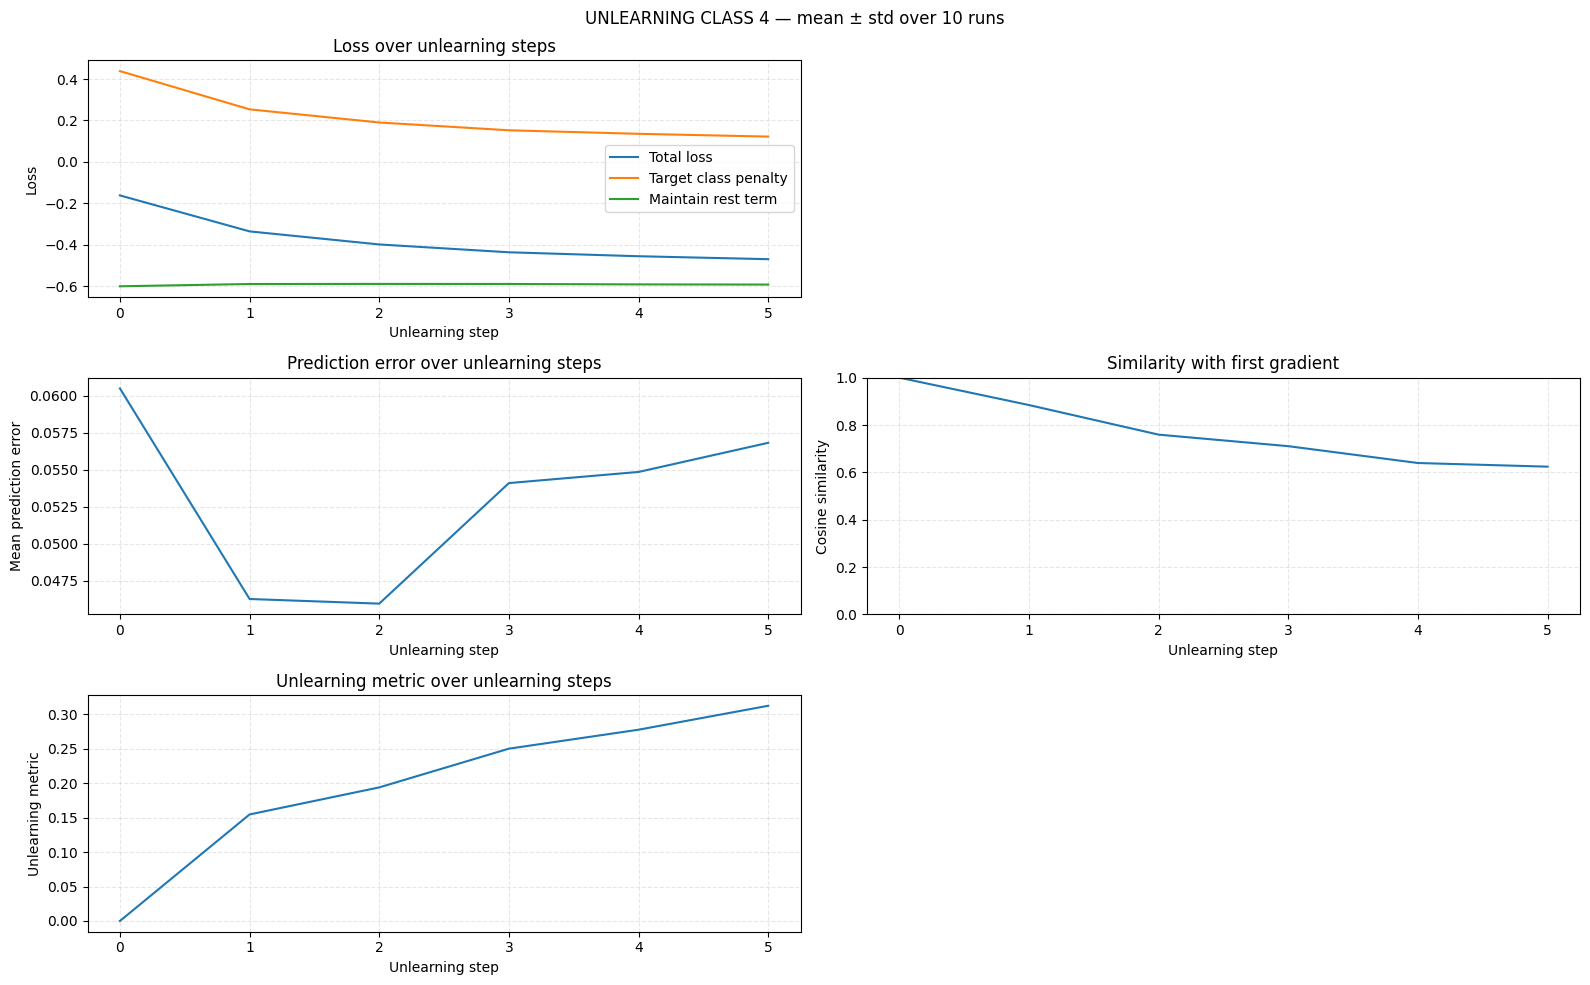

In [12]:
# -----plotting (averaged over runs)-----
def _mean_std(runs: list[list[float]]):
    """Return mean, std and common length across runs (robust to unequal lengths)."""
    assert isinstance(runs, list) and len(runs) > 0, "No runs to aggregate."
    min_len = min(len(r) for r in runs)
    arr = np.stack([np.asarray(r[:min_len], dtype=float) for r in runs], axis=0)  # [num_runs, T]
    mu = arr.mean(axis=0)
    sd = arr.std(axis=0)
    return mu, sd, min_len

def _plot_band(ax, x, mu, sd, label, clamp=None):
    lo, hi = mu - sd, mu + sd
    if clamp is not None:
        lo = np.clip(lo, clamp[0], clamp[1])
        hi = np.clip(hi, clamp[0], clamp[1])
    ax.plot(x, mu, label=label)
    ax.fill_between(x, lo, hi, alpha=0.2, linewidth=0)

num_runs = len(loss_all)
loss_mu, loss_sd, T = _mean_std(loss_all)
tgt_mu,  tgt_sd,  _ = _mean_std(target_term_all)
rest_mu, rest_sd, _ = _mean_std(maintain_rest_all)
diff_mu, diff_sd, _ = _mean_std(diffs_all)
cos_mu,  cos_sd,  _ = _mean_std(cosine_sim_all)
met_mu,  met_sd,  _ = _mean_std(metric_all)

x = np.arange(T)

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle(f"UNLEARNING CLASS {target_class} — mean ± std over {num_runs} runs")

# ------- (0,0) loss components -------
ax = axes[0, 0]
_plot_band(ax, x, loss_mu, loss_sd, "Total loss")
_plot_band(ax, x, tgt_mu,  tgt_sd,  "Target class penalty")
_plot_band(ax, x, rest_mu, rest_sd, "Maintain rest term")
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Loss")
ax.set_title("Loss over unlearning steps")
ax.grid(linestyle="--", alpha=0.3)
ax.legend()

# ------- (0,1) disabled (bar graph ignored) -------
axes[0, 1].axis("off")

# ------- (1,0) mean prediction error -------
ax = axes[1, 0]
_plot_band(ax, x, diff_mu, diff_sd, "Mean |pred - true|")
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Mean prediction error")
ax.set_title("Prediction error over unlearning steps")
# y-lims with small padding
ymin, ymax = (diff_mu - diff_sd).min(), (diff_mu + diff_sd).max()
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
ax.set_ylim(ymin - pad, ymax + pad)
ax.grid(linestyle="--", alpha=0.3)

# ------- (1,1) gradient cosine similarity -------
ax = axes[1, 1]
_plot_band(ax, x, cos_mu, cos_sd, "Cosine similarity", clamp=(0.0, 1.0))
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Cosine similarity")
ax.set_title("Similarity with first gradient")
ax.set_ylim(0, 1)
ax.grid(linestyle="--", alpha=0.3)

# ------- (2,0) unlearning metric -------
ax = axes[2, 0]
_plot_band(ax, x, met_mu, met_sd, "Unlearning metric")
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Unlearning metric")
ax.set_title("Unlearning metric over unlearning steps")
ymin, ymax = (met_mu - met_sd).min(), (met_mu + met_sd).max()
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
ax.set_ylim(ymin - pad, ymax + pad)
ax.grid(linestyle="--", alpha=0.3)

# hide the (2,1) subplot (bottom right)
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

# Depricated

In [13]:
assert isinstance(RegressorLens, nn.Module), f"RegressorLens is not an instance of torch.nn.Module but {type(RegressorLens)}"
input_weights: np.ndarray = weights_test[MODEL_IDX]
steps: int = 200
step_size: float = 1.0
target_class: int = 5
og_config: pd.Series = configs_test.iloc[MODEL_IDX]

print("Starting unlearning procedure")
diffs_list = []
loss_list = []
target_term_list = []
mse_term_list = []
mae_term_list = []

# convert input weights to tensor for optimization
doctored_input_weights = torch.tensor(input_weights, requires_grad=True, dtype=torch.float32)

RegressorLens.eval()

# optimize only the INPUT weights
for param in RegressorLens.parameters():
    param.requires_grad = False

for i in tqdm(range(steps), desc="Unlearning in progress"):
    pred: torch.Tensor = RegressorLens(doctored_input_weights.unsqueeze(0)).squeeze(0)  # forward pass

    # this is expensive: a new model needs to be reconstructed and evaluated at every step
    true = torch.tensor(
        test_network_accuracy(doctored_input_weights.detach().numpy(), og_config["config.activation"])[1],
        dtype=torch.float32,
    )

    loss = unlearning_and_faithfulness_loss(pred, true, target_class)

    # for analysis
    target_term: float = pred[target_class].item()
    # mse_term: float = ((true - pred) ** 2).mean().item()
    mae_term: float = (true - pred).abs().mean().item()

    loss.backward()  # compute gradients
    gradients = doctored_input_weights.grad

    with torch.no_grad():
        doctored_input_weights -= step_size * gradients  # gradient step # type: ignore
        doctored_input_weights.grad.zero_()  # zero gradients # type: ignore

    mean_diff = abs((pred.detach().numpy() - np.array(true)).mean())

    loss_list.append(loss.item())
    target_term_list.append(target_term)
    # mse_term_list.append(mse_term)
    mae_term_list.append(mae_term)
    diffs_list.append(mean_diff)

NameError: name 'weights_test' is not defined